# Toroidal K-Means Clustering on a Torus

This notebook demonstrates clustering on a **torus** — a donut-shaped surface where **both** dimensions wrap around.

## What is a Torus?

**Analogy:** Imagine playing an old-school arcade game (like Pac-Man or Asteroids). When you go off the right edge of the screen, you reappear on the left. When you go off the top, you reappear at the bottom. That flat rectangle with wraparound edges *is* a flat torus. If you physically bent and glued those edges together, you'd get a donut.

## Why Does This Matter for Clustering?

Many real-world variables are **periodic** — they wrap around:
- **Time of day** (23:59 → 00:00)
- **Day of week** (Sunday → Monday)
- **Compass bearing** (359° → 0°)
- **Molecular dihedral angles** (protein structure analysis)

When you have **two** periodic dimensions, your data lives on a torus. Using Euclidean distance would say that 23:55 on Sunday and 00:05 on Monday are far apart — but toroidal distance correctly treats them as 10 minutes apart.

## The Flat Torus Metric

For a torus with periods $L_1$ and $L_2$, the distance wraps in each dimension independently:

$$d_{\text{torus}}(\mathbf{u}, \mathbf{v}) = \sqrt{\min(|u_1-v_1|,\; L_1 - |u_1-v_1|)^2 + \min(|u_2-v_2|,\; L_2 - |u_2-v_2|)^2}$$

Each coordinate takes the shorter path: either direct or "the long way around."

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch, Rectangle

np.random.seed(42)

# Torus parameters
# We use angular coordinates: theta ∈ [0, 2π) and phi ∈ [0, 2π)
# theta = angle around the tube (small circle)
# phi   = angle around the hole  (big circle)
L = 2 * np.pi  # period in both dimensions

# For 3D embedding:
R_major = 3.0   # distance from center of hole to center of tube
R_minor = 1.0   # radius of the tube

print("Setup complete!")
print(f"Torus: R_major={R_major}, R_minor={R_minor}")
print(f"Both coordinates are periodic with period 2π")

Setup complete!
Torus: R_major=3.0, R_minor=1.0
Both coordinates are periodic with period 2π


## 2. Generate Pre-Clustered Points on a Torus

We place cluster centers at different (θ, φ) positions on the torus, including some that straddle the wraparound boundary — this is where toroidal distance really shines.

In [2]:
def wrap_to_period(x, period=2*np.pi):
    """Wrap values to [0, period)."""
    return x % period


def generate_torus_clusters(n_points=300, n_clusters=5, spread=0.35, seed=42):
    """
    Generate pre-clustered points on a flat torus [0, 2π) × [0, 2π).
    
    Some clusters are placed near the wraparound boundary to demonstrate
    the importance of toroidal distance.
    """
    rng = np.random.default_rng(seed)
    
    # Cluster centers (theta, phi) — note some are near 0 or 2π boundary
    center_configs = [
        (0.3, 0.2),          # near the (0,0) corner — straddles wraparound!
        (3.5, 1.5),          # middle area
        (1.0, 4.5),          # upper left
        (5.0, 5.8),          # near the (2π, 2π) corner — straddles wraparound!
        (4.0, 3.2),          # center-right
    ]
    
    centers = np.array(center_configs[:n_clusters])
    
    points_per_cluster = n_points // n_clusters
    all_points = []
    all_labels = []
    
    for i in range(n_clusters):
        n = points_per_cluster if i < n_clusters - 1 else n_points - points_per_cluster * (n_clusters - 1)
        
        noise = rng.normal(0, spread, size=(n, 2))
        cluster_pts = centers[i] + noise
        
        # Wrap to [0, 2π)
        cluster_pts = wrap_to_period(cluster_pts)
        
        all_points.append(cluster_pts)
        all_labels.append(np.full(n, i))
    
    return np.concatenate(all_points), np.concatenate(all_labels), centers


# Generate
K = 5
points, true_labels, true_centers = generate_torus_clusters(n_points=300, n_clusters=K)

print(f"Generated {len(points)} points in {K} clusters")
print(f"Coordinate ranges: θ ∈ [{points[:,0].min():.2f}, {points[:,0].max():.2f}], "
      f"φ ∈ [{points[:,1].min():.2f}, {points[:,1].max():.2f}]")
print(f"\nCluster centers (θ, φ):")
for i, c in enumerate(true_centers):
    print(f"  Cluster {i+1}: ({c[0]:.2f}, {c[1]:.2f})  "
          f"→ ({np.rad2deg(c[0]):.0f}°, {np.rad2deg(c[1]):.0f}°)")

Generated 300 points in 5 clusters
Coordinate ranges: θ ∈ [0.01, 6.28], φ ∈ [0.01, 6.27]

Cluster centers (θ, φ):
  Cluster 1: (0.30, 0.20)  → (17°, 11°)
  Cluster 2: (3.50, 1.50)  → (201°, 86°)
  Cluster 3: (1.00, 4.50)  → (57°, 258°)
  Cluster 4: (5.00, 5.80)  → (286°, 332°)
  Cluster 5: (4.00, 3.20)  → (229°, 183°)


## 3. Toroidal Distance

The key: in each dimension, take the **shorter** of the two possible paths (direct or wraparound).

In [3]:
def torus_distance(u, v, period=2*np.pi):
    """
    Compute flat torus distance between points u and v.
    
    Each dimension wraps with the given period.
    u, v: arrays of shape (2,) or (N, 2)
    """
    diff = np.abs(u - v)
    # Take shorter path in each dimension
    wrapped_diff = np.minimum(diff, period - diff)
    return np.sqrt(np.sum(wrapped_diff**2, axis=-1))


def torus_distance_matrix(points, centers, period=2*np.pi):
    """Distance matrix (n_points × n_centers) on flat torus."""
    n_points = len(points)
    n_centers = len(centers)
    dist_matrix = np.zeros((n_points, n_centers))
    
    for j in range(n_centers):
        dist_matrix[:, j] = torus_distance(points, centers[j], period)
    
    return dist_matrix


# Sanity checks
period = 2 * np.pi

# Same point → 0
d0 = torus_distance(np.array([1.0, 2.0]), np.array([1.0, 2.0]))
print(f"Same point:       d = {d0:.4f}  (expected: 0.0)")

# Direct distance
d1 = torus_distance(np.array([1.0, 1.0]), np.array([2.0, 1.0]))
print(f"Direct (1,1)→(2,1): d = {d1:.4f}  (expected: 1.0)")

# Wraparound: (0.1, 0) to (6.18, 0) — should be ~0.2, not ~6.08
d_wrap = torus_distance(np.array([0.1, 0.0]), np.array([2*np.pi - 0.1, 0.0]))
d_nowrap = abs(0.1 - (2*np.pi - 0.1))
print(f"\nWraparound test: (0.1, 0) → (6.18, 0)")
print(f"  Toroidal distance: {d_wrap:.4f}  (correctly wraps!)")
print(f"  Naive |diff|:      {d_nowrap:.4f}  (wrong — ignores wraparound)")

# Max possible distance on torus
d_max = torus_distance(np.array([0.0, 0.0]), np.array([np.pi, np.pi]))
print(f"\nMax torus distance: {d_max:.4f}  (expected: π√2 ≈ {np.pi * np.sqrt(2):.4f})")

Same point:       d = 0.0000  (expected: 0.0)
Direct (1,1)→(2,1): d = 1.0000  (expected: 1.0)

Wraparound test: (0.1, 0) → (6.18, 0)
  Toroidal distance: 0.2000  (correctly wraps!)
  Naive |diff|:      6.0832  (wrong — ignores wraparound)

Max torus distance: 4.4429  (expected: π√2 ≈ 4.4429)


## 4. Toroidal K-Means

Key adaptation: the **circular mean** for centroid updates. You can't just average angles — averaging 1° and 359° gives 180° instead of the correct 0°.

The circular mean uses a trigonometric trick:
$$\bar{\theta} = \text{atan2}\left(\frac{1}{N}\sum \sin(\theta_i),\; \frac{1}{N}\sum \cos(\theta_i)\right)$$

We apply this independently to each dimension of the torus.

In [4]:
def circular_mean(angles, period=2*np.pi):
    """
    Compute the circular (angular) mean of a set of angles.
    Handles wraparound correctly.
    """
    # Normalize to [0, 2π) for trig
    normalized = angles * (2 * np.pi / period)
    mean_sin = np.mean(np.sin(normalized))
    mean_cos = np.mean(np.cos(normalized))
    mean_angle = np.arctan2(mean_sin, mean_cos)
    # Convert back to [0, period)
    return (mean_angle * period / (2 * np.pi)) % period


def torus_centroid(points, period=2*np.pi):
    """Compute torus centroid by applying circular mean to each dimension."""
    return np.array([
        circular_mean(points[:, 0], period),
        circular_mean(points[:, 1], period)
    ])


def torus_kmeans(points, k=5, max_iter=100, tol=1e-6, period=2*np.pi, seed=123):
    """
    K-means clustering on a flat torus.
    Uses toroidal distance + circular mean centroids.
    """
    rng = np.random.default_rng(seed)
    n = len(points)
    
    init_idx = rng.choice(n, size=k, replace=False)
    centers = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # Assignment
        dist_matrix = torus_distance_matrix(points, centers, period)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        # Update
        new_centers = np.zeros_like(centers)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centers[j] = points[rng.choice(n)]
            else:
                new_centers[j] = torus_centroid(members, period)
        
        shift = torus_distance(centers, new_centers, period)
        centers = new_centers
        
        if np.max(shift) < tol:
            print(f"Torus K-Means converged at iteration {iteration + 1}")
            break
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, centers, history


# Run toroidal K-means
torus_labels, torus_centers, torus_history = torus_kmeans(points, k=K, max_iter=100)

print(f"\nCluster sizes: {[np.sum(torus_labels == i) for i in range(K)]}")
print(f"Final total intra-cluster distance: {torus_history[-1]:.4f}")
print(f"\nFinal centroids (θ, φ):")
for i, c in enumerate(torus_centers):
    print(f"  Cluster {i+1}: ({c[0]:.2f}, {c[1]:.2f})")

Torus K-Means converged at iteration 5

Cluster sizes: [np.int64(26), np.int64(60), np.int64(35), np.int64(120), np.int64(59)]
Final total intra-cluster distance: 183.5020

Final centroids (θ, φ):
  Cluster 1: (6.28, 0.07)
  Cluster 2: (1.07, 4.48)
  Cluster 3: (0.48, 0.24)
  Cluster 4: (3.70, 2.35)
  Cluster 5: (4.99, 5.78)


## 5. Visualization

### 5a. 3D Torus Surface Plot

The flat torus coordinates (θ, φ) embedded as a 3D donut, with points colored by cluster.

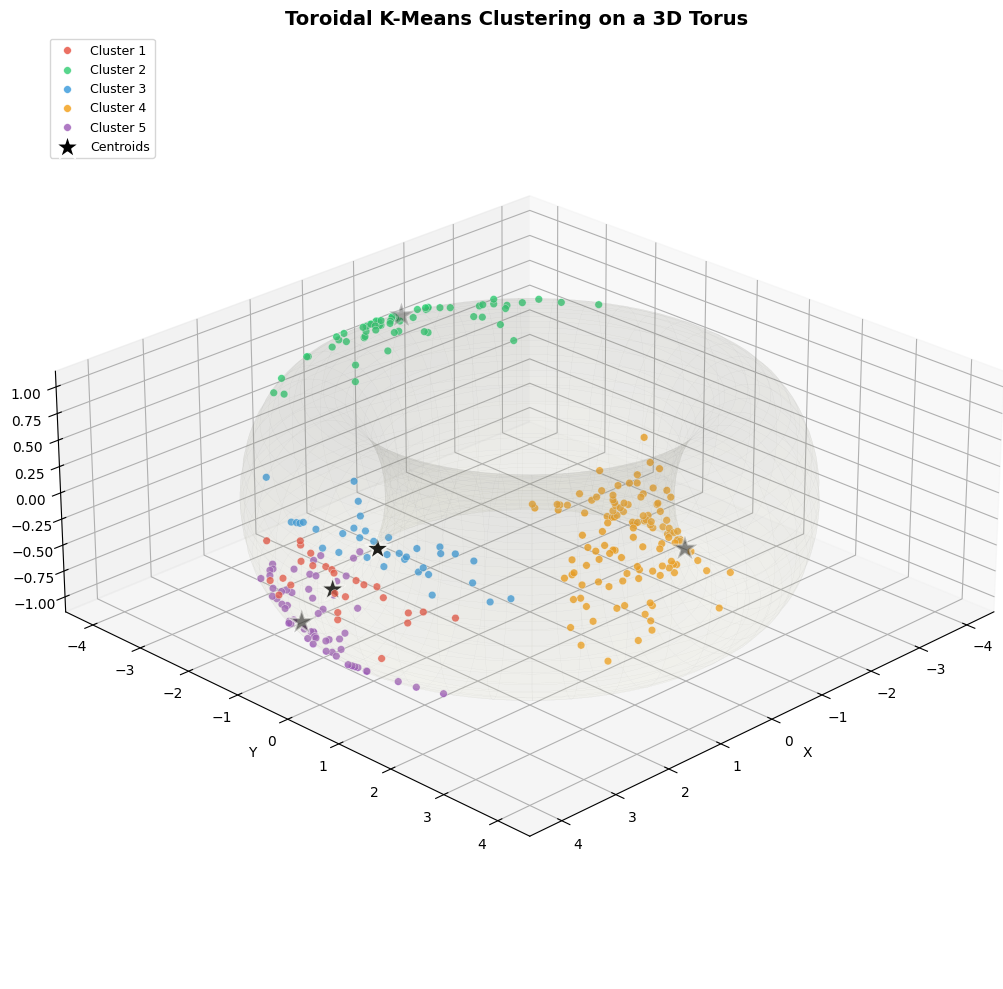

In [5]:
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

def torus_to_3d(theta, phi, R=R_major, r=R_minor):
    """
    Map flat torus coordinates (theta, phi) to 3D embedding.
    theta: angle around tube (small circle)
    phi:   angle around hole (big circle)
    """
    x = (R + r * np.cos(theta)) * np.cos(phi)
    y = (R + r * np.cos(theta)) * np.sin(phi)
    z = r * np.sin(theta)
    return x, y, z


# Torus wireframe
theta_grid = np.linspace(0, 2*np.pi, 80)
phi_grid = np.linspace(0, 2*np.pi, 80)
theta_mesh, phi_mesh = np.meshgrid(theta_grid, phi_grid)
tx, ty, tz = torus_to_3d(theta_mesh, phi_mesh)

# Data points in 3D
px, py, pz = torus_to_3d(points[:, 0], points[:, 1])
cx, cy, cz = torus_to_3d(torus_centers[:, 0], torus_centers[:, 1])

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Torus surface
ax.plot_surface(tx, ty, tz, alpha=0.08, color='lightyellow', edgecolor='gray', linewidth=0.1)

# Points by cluster
for i in range(K):
    mask = torus_labels == i
    ax.scatter(px[mask], py[mask], pz[mask],
               c=cluster_colors[i], s=30, alpha=0.8, label=f'Cluster {i+1}',
               depthshade=True, edgecolors='white', linewidths=0.3)

# Centroids
ax.scatter(cx, cy, cz, c='black', marker='*', s=350, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Toroidal K-Means Clustering on a 3D Torus', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_box_aspect([1, 1, 0.4])
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

### 5b. 2D Unwrapped Torus (Flat Square with Wraparound)

This is the "Pac-Man view" — the torus unfolded into a flat square. The key thing to observe: clusters near the edges wrap around seamlessly. Toroidal K-means handles this correctly; Euclidean K-means would split them.

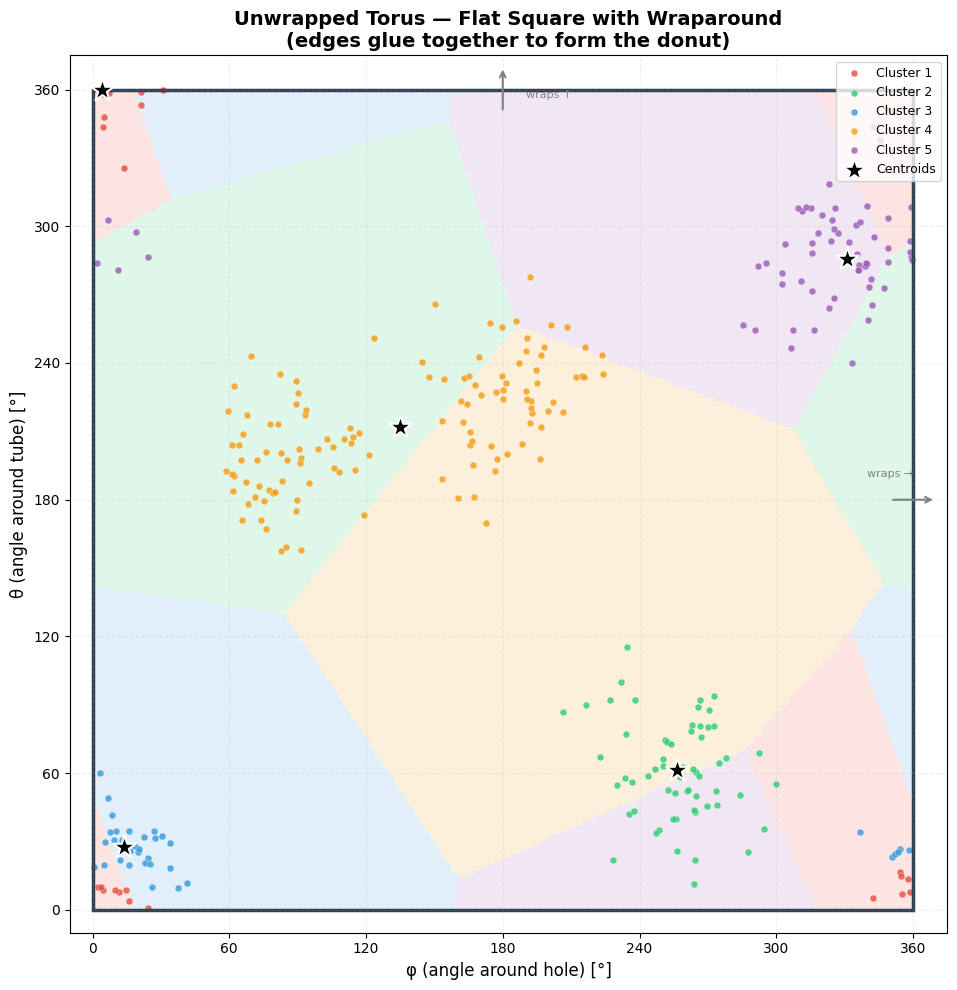

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

# Background: Voronoi regions using torus distance
grid_res = 250
g_theta = np.linspace(0, 2*np.pi, grid_res)
g_phi = np.linspace(0, 2*np.pi, grid_res)
g_theta_mesh, g_phi_mesh = np.meshgrid(g_theta, g_phi)
grid_pts = np.stack([g_theta_mesh.ravel(), g_phi_mesh.ravel()], axis=-1)

grid_dists = torus_distance_matrix(grid_pts, torus_centers)
grid_labels_bg = np.argmin(grid_dists, axis=1).reshape(grid_res, grid_res)

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])
ax.imshow(grid_labels_bg, extent=[0, 360, 0, 360],
          origin='lower', aspect='equal', cmap=cmap_bg, interpolation='nearest')

# Plot data points
for i in range(K):
    mask = torus_labels == i
    ax.scatter(np.rad2deg(points[mask, 1]), np.rad2deg(points[mask, 0]),
               c=cluster_colors[i], s=25, alpha=0.8, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}')

# Plot centroids
ax.scatter(np.rad2deg(torus_centers[:, 1]), np.rad2deg(torus_centers[:, 0]),
           c='black', marker='*', s=300, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

# Wraparound indicators — arrows at boundaries
ax.annotate('', xy=(370, 180), xytext=(350, 180),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('wraps →', xy=(360, 190), fontsize=8, color='gray', ha='right')
ax.annotate('', xy=(180, 370), xytext=(180, 350),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('wraps ↑', xy=(190, 360), fontsize=8, color='gray', ha='left', va='top')

# Add the square boundary to emphasize it's a fundamental domain
rect = Rectangle((0, 0), 360, 360, fill=False, edgecolor='#2c3e50', linewidth=2.5)
ax.add_patch(rect)

ax.set_xlim(-10, 375)
ax.set_ylim(-10, 375)
ax.set_xlabel('φ (angle around hole) [°]', fontsize=12)
ax.set_ylabel('θ (angle around tube) [°]', fontsize=12)
ax.set_title('Unwrapped Torus — Flat Square with Wraparound\n'
             '(edges glue together to form the donut)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_xticks(np.arange(0, 361, 60))
ax.set_yticks(np.arange(0, 361, 60))

plt.tight_layout()
plt.show()

### 5c. Convergence Plot

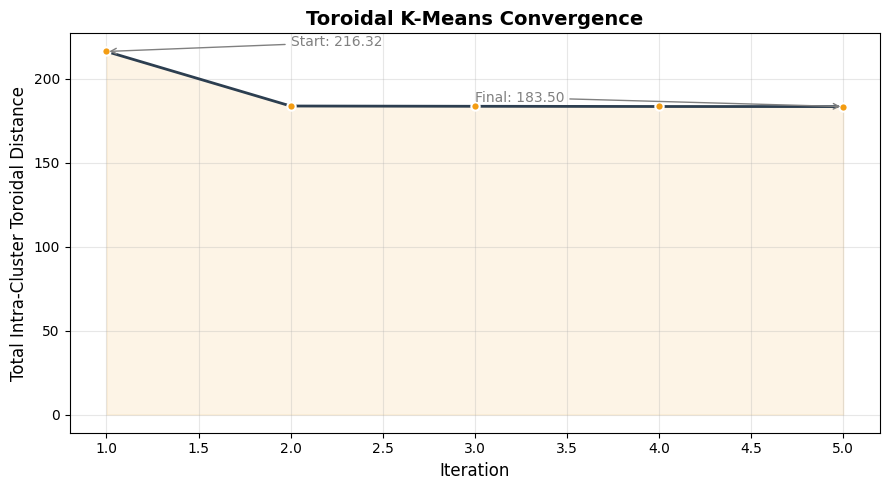

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

iterations = range(1, len(torus_history) + 1)

ax.plot(iterations, torus_history, 'o-', color='#2c3e50', markersize=6,
        linewidth=2, markerfacecolor='#f39c12', markeredgecolor='white', markeredgewidth=1.5)
ax.fill_between(iterations, torus_history, alpha=0.1, color='#f39c12')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Total Intra-Cluster Toroidal Distance', fontsize=12)
ax.set_title('Toroidal K-Means Convergence', fontsize=14, fontweight='bold')

ax.annotate(f'Start: {torus_history[0]:.2f}', xy=(1, torus_history[0]),
            xytext=(2, torus_history[0] + 3),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
ax.annotate(f'Final: {torus_history[-1]:.2f}', xy=(len(torus_history), torus_history[-1]),
            xytext=(max(1, len(torus_history) - 2), torus_history[-1] + 3),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Euclidean vs Toroidal — The Wraparound Problem

This is where the torus metric really earns its keep. Let's run standard Euclidean K-means on the same points and see how it mishandles clusters that straddle the boundary.

In [8]:
def euclidean_kmeans_2d(points, k=5, max_iter=100, tol=1e-6, seed=123):
    """Standard Euclidean K-means (no wraparound awareness)."""
    rng = np.random.default_rng(seed)
    n = len(points)
    
    init_idx = rng.choice(n, size=k, replace=False)
    centers = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # Euclidean distance (no wrapping)
        dist_matrix = np.zeros((n, k))
        for j in range(k):
            dist_matrix[:, j] = np.linalg.norm(points - centers[j], axis=1)
        
        labels = np.argmin(dist_matrix, axis=1)
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        new_centers = np.zeros_like(centers)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centers[j] = points[rng.choice(n)]
            else:
                new_centers[j] = members.mean(axis=0)  # arithmetic mean — breaks on wraparound!
        
        shift = np.max(np.linalg.norm(centers - new_centers, axis=1))
        centers = new_centers
        
        if shift < tol:
            print(f"Euclidean K-Means converged at iteration {iteration + 1}")
            break
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, centers, history


# Run Euclidean K-means
euc_labels, euc_centers, euc_history = euclidean_kmeans_2d(points, k=K, max_iter=100)
print(f"Euclidean cluster sizes: {[np.sum(euc_labels == i) for i in range(K)]}")

Euclidean K-Means converged at iteration 5
Euclidean cluster sizes: [np.int64(12), np.int64(37), np.int64(60), np.int64(133), np.int64(58)]


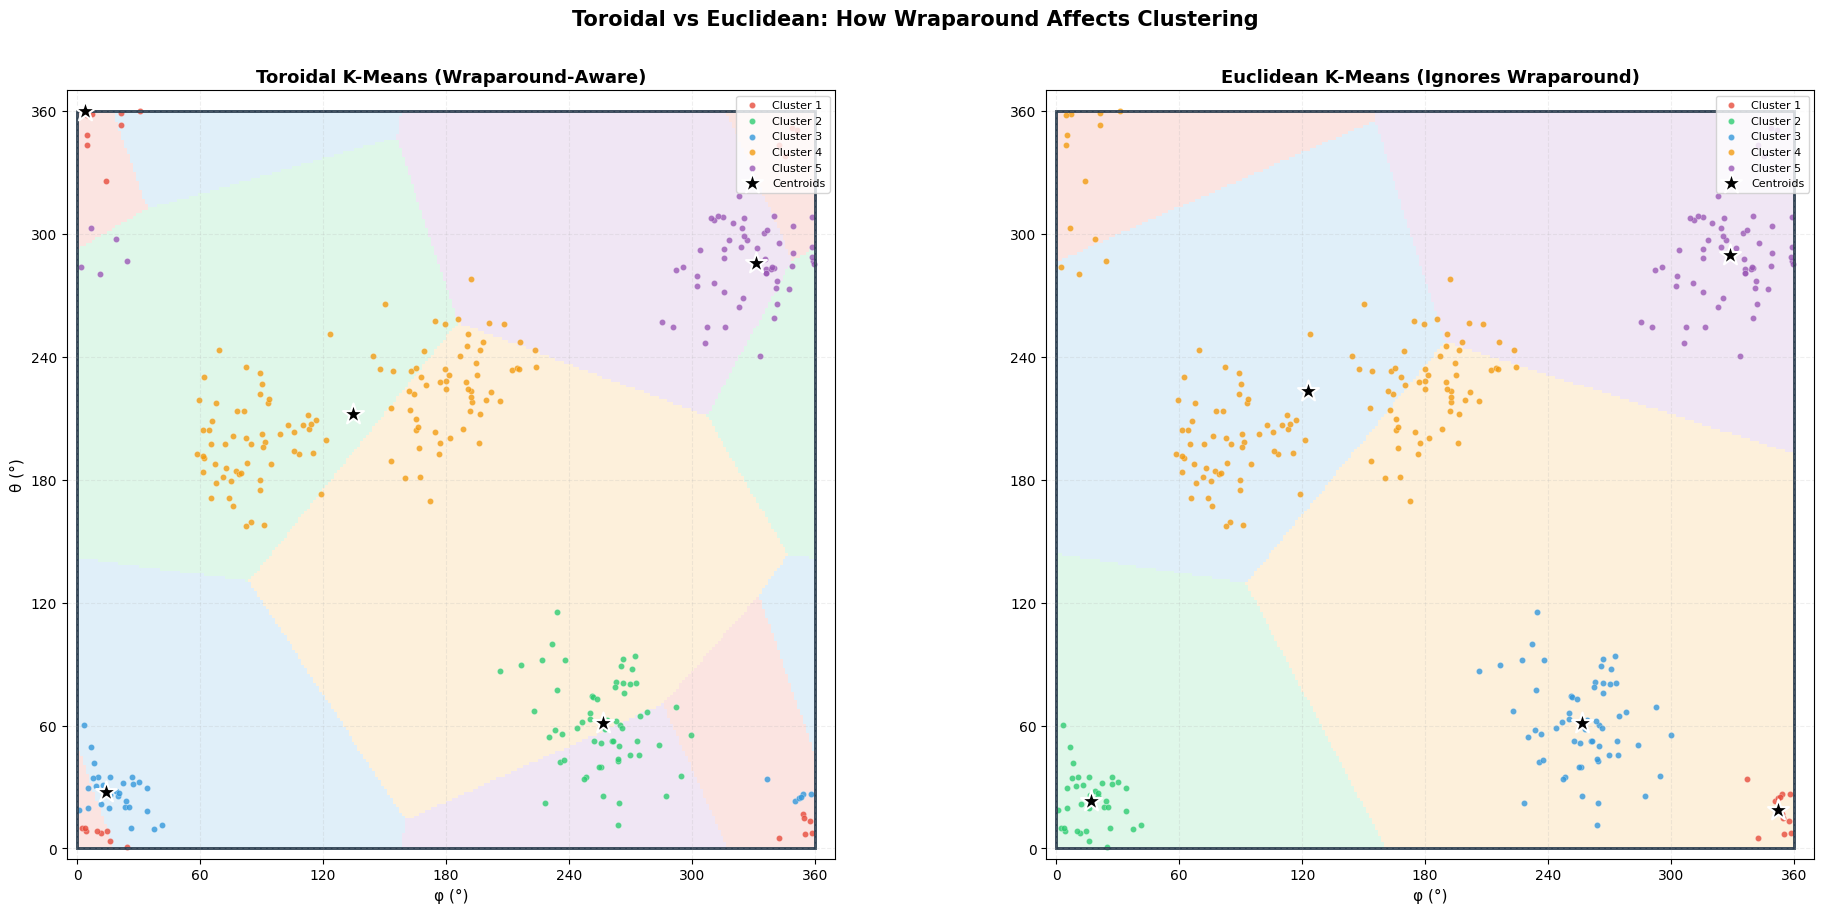

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

configs = [
    ('Toroidal K-Means (Wraparound-Aware)', torus_labels, torus_centers, True),
    ('Euclidean K-Means (Ignores Wraparound)', euc_labels, euc_centers, False),
]

for idx, (title, lbls, ctrs, use_torus) in enumerate(configs):
    ax = axes[idx]
    
    # Voronoi background
    if use_torus:
        g_d = torus_distance_matrix(grid_pts, ctrs)
    else:
        g_d = np.zeros((len(grid_pts), K))
        for j in range(K):
            g_d[:, j] = np.linalg.norm(grid_pts - ctrs[j], axis=1)
    
    g_l = np.argmin(g_d, axis=1).reshape(grid_res, grid_res)
    ax.imshow(g_l, extent=[0, 360, 0, 360], origin='lower', aspect='equal',
              cmap=cmap_bg, interpolation='nearest')
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(np.rad2deg(points[mask, 1]), np.rad2deg(points[mask, 0]),
                   c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
                   linewidths=0.2, label=f'Cluster {i+1}')
    
    ax.scatter(np.rad2deg(ctrs[:, 1]), np.rad2deg(ctrs[:, 0]),
               c='black', marker='*', s=250, edgecolors='white',
               linewidths=1.5, zorder=10, label='Centroids')
    
    rect = Rectangle((0, 0), 360, 360, fill=False, edgecolor='#2c3e50', linewidth=2)
    ax.add_patch(rect)
    
    ax.set_xlim(-5, 370)
    ax.set_ylim(-5, 370)
    ax.set_xticks(np.arange(0, 361, 60))
    ax.set_yticks(np.arange(0, 361, 60))
    ax.set_xlabel('φ (°)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('θ (°)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2, linestyle='--')

plt.suptitle('Toroidal vs Euclidean: How Wraparound Affects Clustering',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6b. Disagreement Analysis

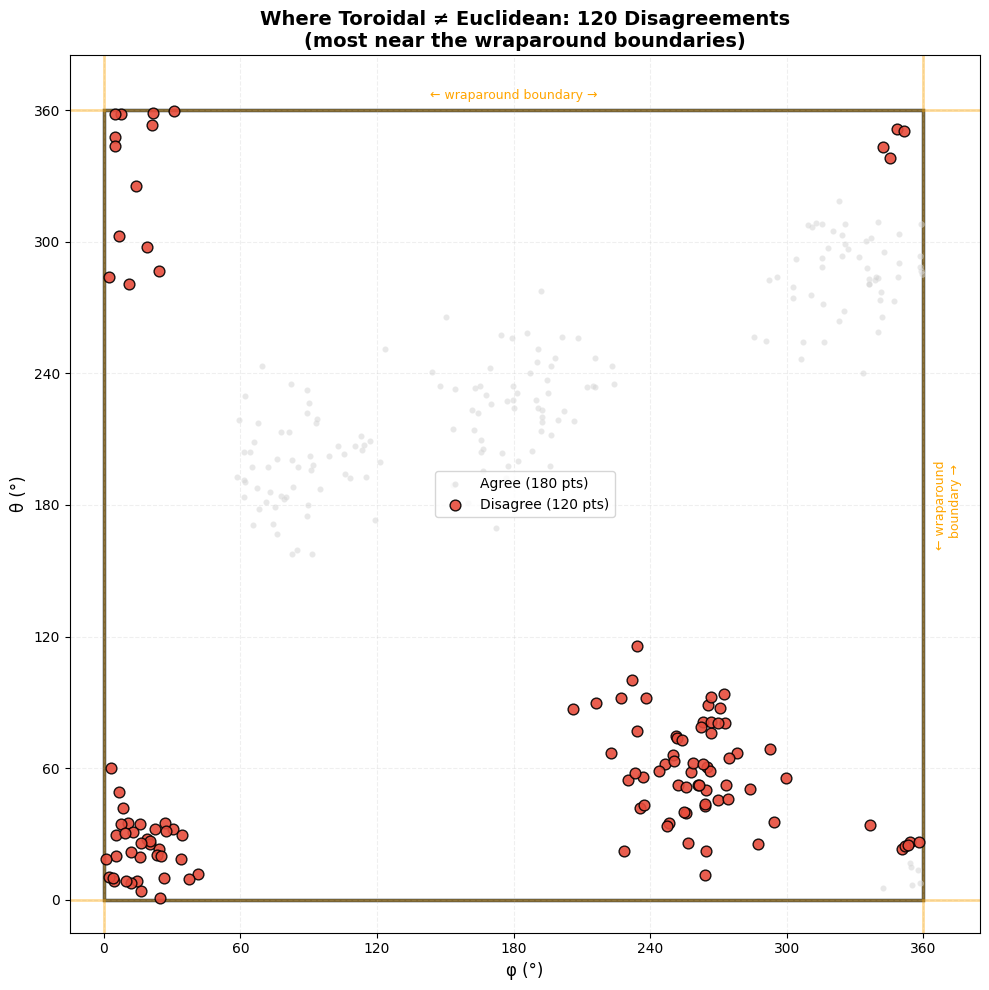

Rand Index (Toroidal vs Euclidean): 0.9381 (93.8%)
Points with different assignments: 120 / 300 (40.0%)

Of the 120 disagreeing points:
  75 (62%) are near a wraparound boundary
  This confirms: Euclidean K-means breaks at the boundary. Toroidal distance fixes it.


In [10]:
from itertools import combinations

def cluster_agreement(labels_a, labels_b):
    """Rand Index between two clusterings."""
    n = len(labels_a)
    agree = 0
    total = 0
    for i, j in combinations(range(n), 2):
        same_a = labels_a[i] == labels_a[j]
        same_b = labels_b[i] == labels_b[j]
        if same_a == same_b:
            agree += 1
        total += 1
    return agree / total


disagree_mask = torus_labels != euc_labels
n_disagree = np.sum(disagree_mask)

fig, ax = plt.subplots(figsize=(10, 10))

rect = Rectangle((0, 0), 360, 360, fill=False, edgecolor='#2c3e50', linewidth=2.5)
ax.add_patch(rect)

# Agreeing points
ax.scatter(np.rad2deg(points[~disagree_mask, 1]), np.rad2deg(points[~disagree_mask, 0]),
           c='lightgray', s=20, alpha=0.5, edgecolors='white',
           linewidths=0.2, label=f'Agree ({np.sum(~disagree_mask)} pts)', zorder=3)

# Disagreeing points
ax.scatter(np.rad2deg(points[disagree_mask, 1]), np.rad2deg(points[disagree_mask, 0]),
           c='#e74c3c', s=60, alpha=0.9, edgecolors='black',
           linewidths=1, label=f'Disagree ({n_disagree} pts)', zorder=5)

# Highlight the boundary zones
ax.axhline(y=0, color='orange', linewidth=2, linestyle='-', alpha=0.4)
ax.axhline(y=360, color='orange', linewidth=2, linestyle='-', alpha=0.4)
ax.axvline(x=0, color='orange', linewidth=2, linestyle='-', alpha=0.4)
ax.axvline(x=360, color='orange', linewidth=2, linestyle='-', alpha=0.4)
ax.text(180, 365, '← wraparound boundary →', ha='center', fontsize=9, color='orange')
ax.text(365, 180, '← wraparound\n   boundary →', ha='left', fontsize=9, color='orange',
        rotation=90, va='center')

ax.set_xlim(-15, 385)
ax.set_ylim(-15, 385)
ax.set_xticks(np.arange(0, 361, 60))
ax.set_yticks(np.arange(0, 361, 60))
ax.set_xlabel('φ (°)', fontsize=12)
ax.set_ylabel('θ (°)', fontsize=12)
ax.set_title(f'Where Toroidal ≠ Euclidean: {n_disagree} Disagreements\n'
             f'(most near the wraparound boundaries)',
             fontsize=14, fontweight='bold')
ax.legend(loc='center', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

# Stats
ri = cluster_agreement(torus_labels, euc_labels)
print(f"Rand Index (Toroidal vs Euclidean): {ri:.4f} ({ri*100:.1f}%)")
print(f"Points with different assignments: {n_disagree} / {len(points)} ({n_disagree/len(points)*100:.1f}%)")

if n_disagree > 0:
    # Check if disagreements are near boundaries
    d_pts = points[disagree_mask]
    near_theta_boundary = np.sum((d_pts[:, 0] < 0.8) | (d_pts[:, 0] > 2*np.pi - 0.8))
    near_phi_boundary = np.sum((d_pts[:, 1] < 0.8) | (d_pts[:, 1] > 2*np.pi - 0.8))
    near_any = np.sum(
        (d_pts[:, 0] < 0.8) | (d_pts[:, 0] > 2*np.pi - 0.8) |
        (d_pts[:, 1] < 0.8) | (d_pts[:, 1] > 2*np.pi - 0.8)
    )
    print(f"\nOf the {n_disagree} disagreeing points:")
    print(f"  {near_any} ({near_any/n_disagree*100:.0f}%) are near a wraparound boundary")
    print(f"  This confirms: Euclidean K-means breaks at the boundary. Toroidal distance fixes it.")

### 6c. Distance Comparison: Toroidal vs Euclidean

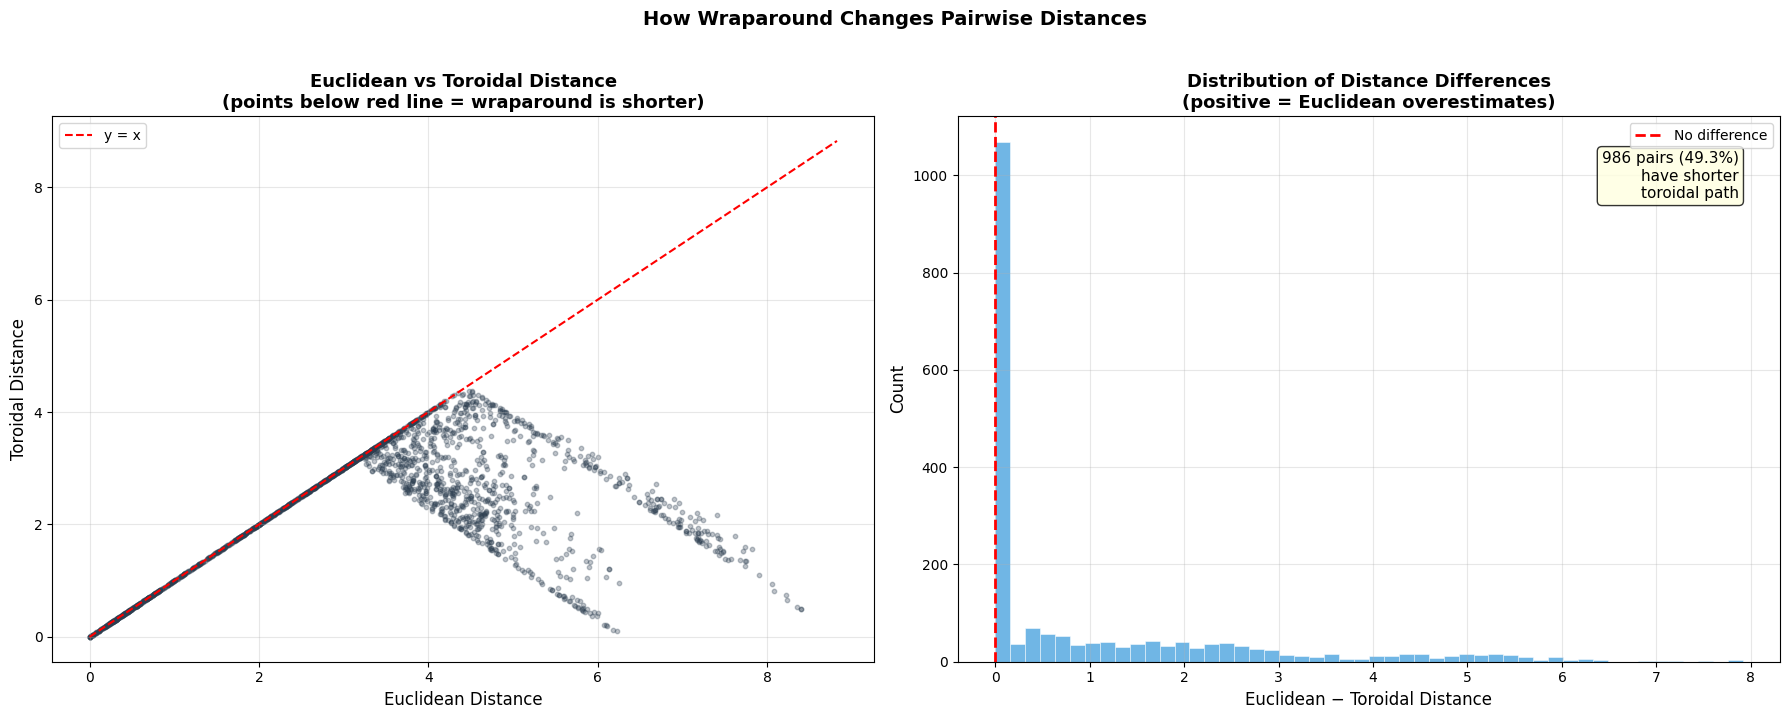

In [11]:
# Sample pairs
rng_s = np.random.default_rng(99)
n_pairs = 2000
ia = rng_s.choice(len(points), size=n_pairs)
ib = rng_s.choice(len(points), size=n_pairs)

d_tor = torus_distance(points[ia], points[ib])
d_euc_pairs = np.linalg.norm(points[ia] - points[ib], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: Euclidean vs Toroidal
axes[0].scatter(d_euc_pairs, d_tor, alpha=0.3, s=10, c='#2c3e50')
lim = max(d_euc_pairs.max(), d_tor.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='y = x')
axes[0].set_xlabel('Euclidean Distance', fontsize=12)
axes[0].set_ylabel('Toroidal Distance', fontsize=12)
axes[0].set_title('Euclidean vs Toroidal Distance\n(points below red line = wraparound is shorter)',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of distance differences
diff = d_euc_pairs - d_tor
axes[1].hist(diff, bins=50, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[1].set_xlabel('Euclidean − Toroidal Distance', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Distance Differences\n(positive = Euclidean overestimates)',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

n_shorter = np.sum(d_tor < d_euc_pairs - 0.01)
axes[1].text(0.95, 0.85, f'{n_shorter} pairs ({n_shorter/n_pairs*100:.1f}%)\nhave shorter\ntoroidal path',
             transform=axes[1].transAxes, fontsize=11, ha='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('How Wraparound Changes Pairwise Distances',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# Build full N×N toroidal distance matrix
n_pts = len(points)
print("Building pairwise toroidal distance matrix...")
D_full = torus_distance_matrix(points, points)  # N×N

# TWCSS baseline: one cluster, centred on circular mean of all points
overall_center = torus_centroid(points)
TWCSS_1 = float(np.sum(torus_distance(points, overall_center) ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, cents_k, _ = torus_kmeans(points, k=k, max_iter=100)
    dists_k = torus_distance(points, cents_k[lbls_k])
    twcss_k = float(np.sum(dists_k ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_full, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 7. Summary

| Aspect | Euclidean K-Means | Toroidal K-Means |
|--------|------------------|------------------|
| **Surface** | Flat plane (infinite, no edges) | Flat torus (finite, wraps around) |
| **Distance** | $\|u - v\|$ | $\sqrt{\sum \min(|d_i|, L_i - |d_i|)^2}$ |
| **Centroid** | Arithmetic mean | Circular mean (per dimension) |
| **Boundary handling** | Hard edges (ignores wrapping) | Seamless wrapping |
| **Best for** | Non-periodic data | Two periodic variables |

### Key Takeaways

1. **Euclidean distance fails at wraparound boundaries.** Points at 1° and 359° are treated as 358° apart instead of 2°. This tears clusters apart.

2. **Circular mean is essential.** Averaging 1° and 359° should give 0°, not 180°. The atan2-based circular mean handles this correctly.

3. **Real-world applications:**
   - Time of day × day of week (user behavior patterns)
   - Wind direction × wind speed cycles
   - Protein dihedral angles (φ, ψ in Ramachandran plots)
   - Compass heading × elevation angle (radar/sonar)

### Project Summary — All Surfaces Covered

| Surface | Distance | Notebook |
|---------|----------|----------|
| Sphere | Haversine (great-circle) | Spherical K-Means |
| Ellipsoid | Vincenty (iterative geodesic) | Spherical K-Means |
| Sphere | Cosine (angular) | Spherical K-Means |
| Hyperbolic plane | Poincaré disk metric | Hyperbolic K-Means |
| Torus | Flat torus (wraparound) | This notebook |